# Loading in the Data and Norms

In [ ]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
from collections import Counter
from datetime import datetime
from sklearn.decomposition import PCA
import seaborn as sns
import spacy
from tqdm import tqdm

# You don't need this next bit of code, this was just to load in the actual text data

#def c2l(commastring): 
#    return commastring.split(', ')

#df = pd.read_csv('fanfics_Greek_myth.csv', converters={'character': c2l, 'category': c2l, 'fandom': c2l, 'relationship': c2l, 'additional tags': c2l,})

/Users/julia.neugarten/opt/anaconda3/lib/python3.9/site-packages/thinc/compat.py:36: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  hasattr(torch, "has_mps")
/Users/julia.neugarten/opt/anaconda3/lib/python3.9/site-packages/thinc/compat.py:37: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  and torch.has_mps  # type: ignore[attr-defined]


In [20]:
# sensorimotor norms downloaded from https://osf.io/rwhs6/overview

norms = pd.read_csv("Lancaster_sensorimotor_norms_for_39707_words.csv")
norms.head(50)

,Word,Auditory.mean,Gustatory.mean,Haptic.mean,Interoceptive.mean,Olfactory.mean,Visual.mean,Foot_leg.mean,Hand_arm.mean,Head.mean,...,N_known.perceptual,List_N.perceptual,Percent_known.perceptual,N_known.action,List_N.action,Percent_known.action,Mean_age.perceptual,Mean_age.action,List#.perceptual,List#.action
0,A,2.214286,0.000000,0.428571,0.000000,0.000000,2.428571,0.000000,0.357143,1.071429,...,14,19,0.736842,14,21,0.666667,36.857143,35.571429,PN_Sample_250.csv,MN_sample_250.csv
1,A CAPPELLA,4.333333,0.000000,0.222222,0.722222,0.000000,1.666667,0.380952,0.428571,2.714286,...,18,19,0.947368,21,21,1.000000,35.722222,35.142857,PN_Sample_237.csv,MN_sample_237.csv
2,AARDVARK,1.625000,0.562500,1.625000,0.062500,1.250000,4.125000,0.176471,0.705882,2.235294,...,16,18,0.888889,17,20,0.850000,36.062500,40.823529,PN_Sample_505.csv,MN_sample_505.csv
3,ABACK,1.294118,0.058824,0.294118,1.352941,0.000000,2.823529,0.000000,0.000000,3.272727,...,17,20,0.850000,11,19,0.578947,43.823529,42.545455,PN_Sample_365.csv,MN_sample_365.csv
4,ABACUS,1.555556,0.166667,3.722222,0.277778,0.111111,3.944444,0.000000,2.473684,2.631579,...,18,19,0.947368,19,21,0.904762,36.777778,34.631579,PN_Sample_606.csv,MN_sample_606.csv
5,ABANDON,0.941176,0.117647,0.294118,2.117647,0.058824,2.176471,1.100000,0.700000,2.450000,...,17,18,0.944444,20,20,1.000000,38.882353,39.100000,PN_sample_329.csv,MN_sample_329.csv
6,ABANDONED,1.444444,0.000000,0.055556,1.666667,0.000000,2.777778,1.315789,1.052632,2.631579,...,18,18,1.000000,19,19,1.000000,37.888889,33.052632,PN_Sample_335.csv,MN_sample_335.csv
7,ABANDONEE,1.937500,0.000000,1.375000,0.562500,0.250000,3.937500,0.764706,0.882353,1.823529,...,16,18,0.888889,17,18,0.944444,43.250000,37.235294,PN_Sample_676.csv,MN_sample_676.csv
8,ABANDONER,0.571429,0.000000,0.142857,1.642857,0.000000,2.214286,0.944444,1.277778,1.722222,...,14,15,0.933333,18,20,0.900000,39.357143,32.500000,PN_Sample_227.csv,MN_sample_227.csv
9,ABANDONMENT,2.133333,0.066667,1.200000,2.933333,0.066667,3.000000,0.523810,0.428571,2.142857,...,15,15,1.000000,21,21,1.000000,37.800000,34.904762,PN_Sample_756.csv,MN_sample_756.csv


In [21]:
norms["Word"] = norms["Word"].str.lower()

# Preprocessing the Fanfiction Data

In [5]:
# Tokenize your corpus 
df["tokens"] = df["body"].str.lower().str.split()


In [52]:
corpus_exploded = df.explode("tokens")

In [53]:
corpus_exploded = corpus_exploded.drop(columns=['title', 'author', 'fandom', 'language', 'published',
       'status', 'status date', 'words', 'chapters', 'comments', 'kudos',
       'bookmarks', 'hits', 'all_kudos', 'all_bookmarks', 'body'])

In [ ]:
len(corpus_exploded)

# we now have one row for each token

28548980

In [ ]:
normcols = ['Word', 'Auditory.mean', 'Gustatory.mean', 'Haptic.mean',
       'Interoceptive.mean', 'Olfactory.mean', 'Visual.mean', 'Foot_leg.mean',
       'Hand_arm.mean', 'Head.mean', 'Mouth.mean', 'Torso.mean', 'Auditory.SD',
       'Gustatory.SD', 'Haptic.SD', 'Interoceptive.SD', 'Olfactory.SD',
       'Visual.SD', 'Foot_leg.SD', 'Hand_arm.SD', 'Head.SD', 'Mouth.SD',
       'Torso.SD']
norms = norms[normcols]


In [ ]:
# save some memory
for col in normcols[1:]:
    norms[col] = norms[col].astype('float16')
    

In [12]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner", "textcat"])
nlp.max_length = 10945772 
spacy.require_cpu()

True

In [14]:
def split_text(text, chunk_size=100_000):
    return [text[i:i+chunk_size] for i in range(0, len(text), chunk_size)]

lemmatized_docs = []

for text in tqdm(df["body"].astype(str)):
    chunks = split_text(text)
    lemmas = []
    for doc in nlp.pipe(chunks, batch_size=10):
        lemmas.extend([token.lemma_ for token in doc if not token.is_punct and not token.is_space])
    lemmatized_docs.append(lemmas)

df["lemmas"] = lemmatized_docs


100%|██████████| 5157/5157 [31:43<00:00,  2.71it/s]  


In [ ]:
corpus = df.explode("lemmas").rename(columns={"lemmas": "lemma"})

In [20]:
# Ensure lemma column in corpus_exploded is lowercase
corpus["lemma_lower"] = corpus["lemma"].str.lower()

# Ensure Word column in norms is lowercase
norms["Word_lower"] = norms["Word"].str.lower()


In [21]:
merged_lemmatized = corpus.merge(
    norms,
    left_on="lemma_lower",  # from your corpus
    right_on="Word_lower",  # from the norms
    how="left"
)


In [22]:
merged_lemmatized.columns

Index(['work_id', 'title', 'author', 'rating', 'category', 'fandom',
       'relationship', 'character', 'additional tags', 'language', 'published',
       'status', 'status date', 'words', 'chapters', 'comments', 'kudos',
       'bookmarks', 'hits', 'all_kudos', 'all_bookmarks', 'body', 'lemma',
       'lemma_lower', 'Word', 'Auditory.mean', 'Gustatory.mean', 'Haptic.mean',
       'Interoceptive.mean', 'Olfactory.mean', 'Visual.mean', 'Foot_leg.mean',
       'Hand_arm.mean', 'Head.mean', 'Mouth.mean', 'Torso.mean', 'Auditory.SD',
       'Gustatory.SD', 'Haptic.SD', 'Interoceptive.SD', 'Olfactory.SD',
       'Visual.SD', 'Foot_leg.SD', 'Hand_arm.SD', 'Head.SD', 'Mouth.SD',
       'Torso.SD', 'Max_strength.perceptual', 'Minkowski3.perceptual',
       'Exclusivity.perceptual', 'Dominant.perceptual', 'Max_strength.action',
       'Minkowski3.action', 'Exclusivity.action', 'Dominant.action',
       'Max_strength.sensorimotor', 'Minkowski3.sensorimotor',
       'Exclusivity.sensorimotor', '

In [38]:
# save file
df_text.to_csv("sensorimotor_lemmatized+metadata.csv", index=False)

## How much of my corpus is covered in the norms?

In [45]:
df = pd.read_csv("sensorimotor_lemmatized+metadata.csv")


In [46]:
# words from your corpus
corpus_vocab = set(merged_lemmatized["lemma_lower"].str.lower().unique())

# words from the sensorimotor norms
norms_vocab = set(norms["Word"].str.lower().unique())

In [47]:
# What is the type coverage (based on unique words)?

covered = corpus_vocab.intersection(norms_vocab)
coverage_ratio = len(covered) / len(corpus_vocab)

print(f"Words in your corpus: {len(corpus_vocab):,}")
print(f"Words covered by norms: {len(covered):,}")
print(f"Coverage: {coverage_ratio:.2%}")

Words in your corpus: 1,110
Words covered by norms: 623
Coverage: 56.13%


In [48]:
# What is the token coverage (by frequency)?

token_total = len(merged_lemmatized)
token_covered = merged_lemmatized["lemma_lower"].str.lower().isin(norms_vocab).sum()
token_coverage_ratio = token_covered / token_total

print(f"Total tokens in corpus:        {token_total:,}")
print(f"Tokens covered by norms:       {token_covered:,}")
print(f"Token coverage: {token_coverage_ratio:.2%}")


Total tokens in corpus:        5,154
Tokens covered by norms:       3,686
Token coverage: 71.52%


In [49]:
norms_vocab = set(norms["Word"].str.lower())

missing_mask = ~merged_lemmatized["lemma_lower"].str.lower().isin(norms_vocab)

missing_words = merged_lemmatized[missing_mask]["lemma_lower"]

missing_counts = missing_words.value_counts().head(50)

print("Top 50 uncovered words in your corpus by frequency:")
print(missing_counts)

# so to conclude: obviously character names are not covered.

Top 50 uncovered words in your corpus by frequency:
lemma_lower
persephone    99
hade          54
apollo        51
icarus        37
aphrodite     34
patroclus     34
artemis       32
i.            31
achille       31
1             29
zeus          24
dionysus      23
hades         21
ariadne       20
achilles      19
demeter       18
athena        17
cassandra     17
helen         16
hermes        15
orpheus       14
hera          13
hestia        13
hektor        11
poseidon      11
eurydice      11
paris         10
ganymede      10
hephaestus    10
hector         9
greek          9
eros           8
prometheus     8
iphigenia      7
hyacinthus     7
olympus        7
~              6
o              5
cerberus       5
perseus        5
penelope       5
thanatos       5
daedalus       5
agamemnon      5
kore           5
ah             5
odysseus       5
thetis         4
diana          4
calliope       4
Name: count, dtype: int64


# Analysis

Be aware that there are two versions of the results dataset to choose from here. The first has one row per story (so a little over 5000 rows) containing the sensorimotor values per modality summed over the entire story after lemmatization. 

The second has one row per token in the original fanfictiond datset (so a little over 28 million rows). In the cell below, uncomment one of the lines of code to select which results dataframe to load. This second dataset was too large to upload to Github so I sent you a file sharing link for it.

In [6]:
# merged means these are scores aggregated at the document level (I think this means scores were summed, so it's unsurprising they are higher)
df = pd.read_csv("sensorimotor_lemmatized+metadata.csv")

# there is also an unmerged version of the dataset but it is very large
# One column per word plus some empty columns for paragraph breaks and stuff means this has over 28 million columns
# Before you uncomment the line of code below, beware it took me over 4 minutes to load this
# df = pd.read_csv("sensorimotor_scores+metadata.gz", compression="gzip")


# Some Stats

In [7]:
modalities = ['Auditory.mean','Gustatory.mean','Haptic.mean', 'Interoceptive.mean', 'Olfactory.mean', 'Visual.mean','Foot_leg.mean', 'Hand_arm.mean', 
              'Head.mean', 'Mouth.mean','Torso.mean']

In [8]:
senses = ['Auditory.mean','Gustatory.mean',
       'Haptic.mean', 'Interoceptive.mean', 'Olfactory.mean', 'Visual.mean']

bodyparts = ['Foot_leg.mean', 'Hand_arm.mean', 'Head.mean', 'Mouth.mean',
       'Torso.mean']

In [9]:
mean_senses = df[senses].mean()
mean_bodyparts = df[bodyparts].mean()

In [53]:
print(mean_senses)

Auditory.mean         1.682056
Gustatory.mean        0.430017
Haptic.mean           1.180605
Interoceptive.mean    1.251998
Olfactory.mean        0.552221
Visual.mean           2.513362
dtype: float64


NB: in the norms paper by Lynnott et al. (https://doi.org/10.3758/s13428-019-01316-z) the mean scores were as follows:

 auditory: 1.51
 gustatory: 0.32
 haptic: 1.07
 interoceptive: 1.03
 olfactory: 0.39
 visual: 2.90
 
In other words, fanfiction scores higher than the other corpus on gustatory and visual.

In [10]:
print(mean_bodyparts)

Foot_leg.mean    0.983046
Hand_arm.mean    1.401654
Head.mean        2.238033
Mouth.mean       1.421956
Torso.mean       0.949824
dtype: float64


In [11]:
std_senses = df[senses].std()
print(std_senses)

Auditory.mean         0.109707
Gustatory.mean        0.061232
Haptic.mean           0.124872
Interoceptive.mean    0.147915
Olfactory.mean        0.061076
Visual.mean           0.136701
dtype: float64


In [12]:
std_bodyparts = df[bodyparts].std()
print(std_bodyparts)

Foot_leg.mean    0.092130
Hand_arm.mean    0.105986
Head.mean        0.105819
Mouth.mean       0.113257
Torso.mean       0.093786
dtype: float64


NB: in the norms paper by Lynnott et al. (https://doi.org/10.3758/s13428-019-01316-z) the mean scores were as follows:

 Foot/leg: 0.81
 Hand/arm: 1.45
 Head: 2.28
 Mouth/throat: 1.26
 Torso: 0.82

In other words, fanfiction scores higher than the other corpus on foot/leg, mouth/throat, and torso

# Radar Plots Full Corpus

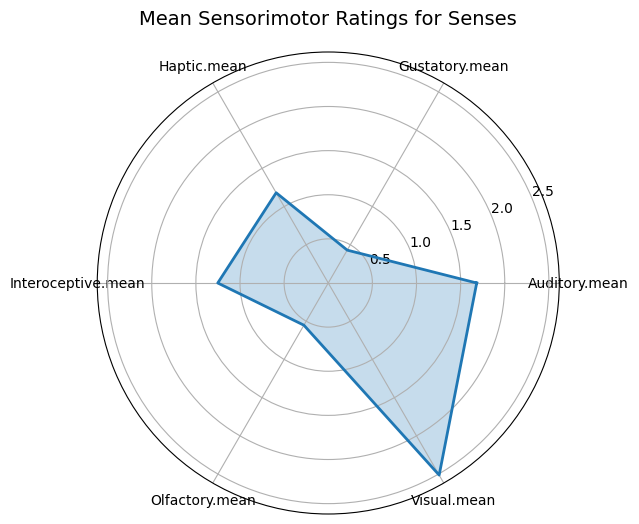

In [13]:
# Prepare angles for radar chart on senses
values = mean_senses.values
labels = mean_senses.index
num_vars = len(labels)

# Repeat the first value to close the circle
values = np.concatenate((values, [values[0]]))
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

# Create the plot
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.plot(angles, values, linewidth=2)
ax.fill(angles, values, alpha=0.25)

# Add labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title("Mean Sensorimotor Ratings for Senses", size=14, pad=20)

plt.show()


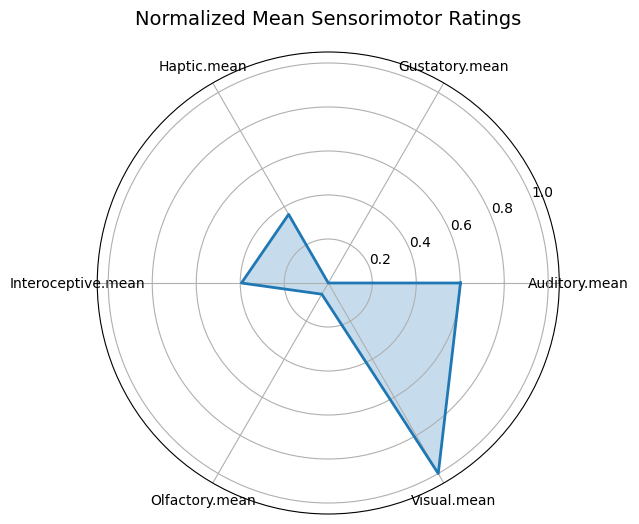

In [14]:
#normalize values for better comparison across dimensions
normalized_mean_senses = (mean_senses - mean_senses.min()) / (mean_senses.max() - mean_senses.min())

# Prepare angles for radar chart
values = normalized_mean_senses.values
labels = normalized_mean_senses.index
num_vars = len(labels)

# Repeat the first value to close the circle
values = np.concatenate((values, [values[0]]))
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

# Create the plot
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.plot(angles, values, linewidth=2)
ax.fill(angles, values, alpha=0.25)

# Add labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title("Normalized Mean Sensorimotor Ratings", size=14, pad=20)

plt.show()


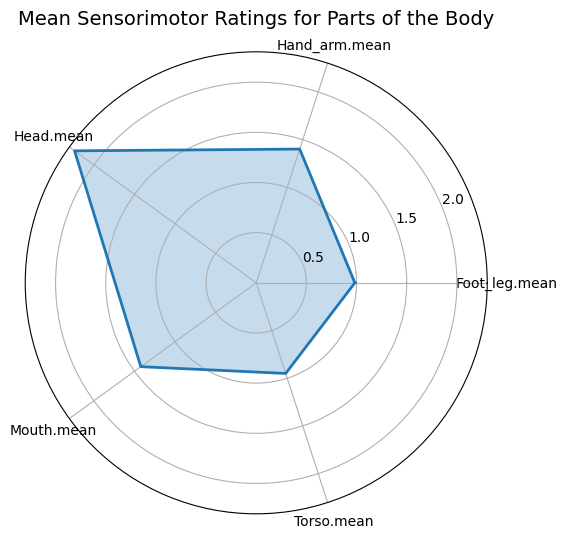

In [15]:
# Prepare angles for radar chart on bodyparts
values = mean_bodyparts.values
labels = mean_bodyparts.index
num_vars = len(labels)

# Repeat the first value to close the circle
values = np.concatenate((values, [values[0]]))
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

# Create the plot
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.plot(angles, values, linewidth=2)
ax.fill(angles, values, alpha=0.25)

# Add labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title("Mean Sensorimotor Ratings for Parts of the Body", size=14, pad=20)

plt.show()

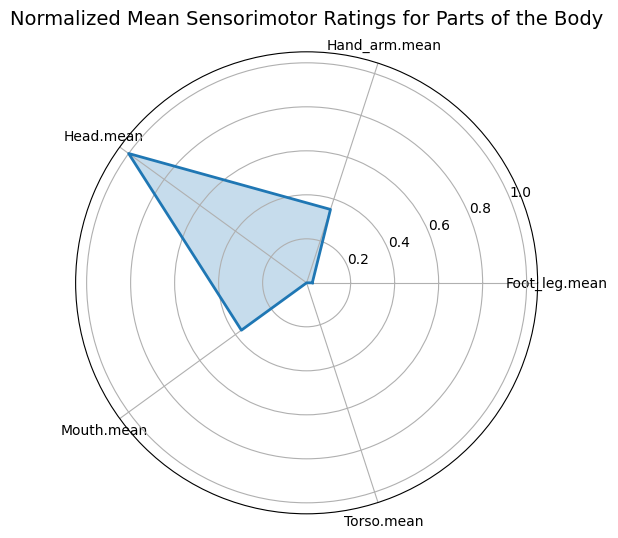

In [16]:
#normalize values for better comparison across dimensions
normalized_mean_bodyparts = (mean_bodyparts - mean_bodyparts.min()) / (mean_bodyparts.max() - mean_bodyparts.min())

# Prepare angles for radar chart
values = normalized_mean_bodyparts.values
labels = normalized_mean_bodyparts.index
num_vars = len(labels)

# Repeat the first value to close the circle
values = np.concatenate((values, [values[0]]))
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

# Create the plot
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.plot(angles, values, linewidth=2)
ax.fill(angles, values, alpha=0.25)

# Add labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title("Normalized Mean Sensorimotor Ratings for Parts of the Body", size=14, pad=20)

plt.show()

# PCA

This is not recommended to run, it takes a long time. Instead you can find the pca's in a separate folder in this repo, both on lemmatized and unlemmatized data and both a version with the data aggegated by text and a version based only on a sample of the data.

In [ ]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(merged_lemmatized[modalities].fillna(0))

plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.5)
plt.title("Sensorimotor PCA Map of Corpus")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


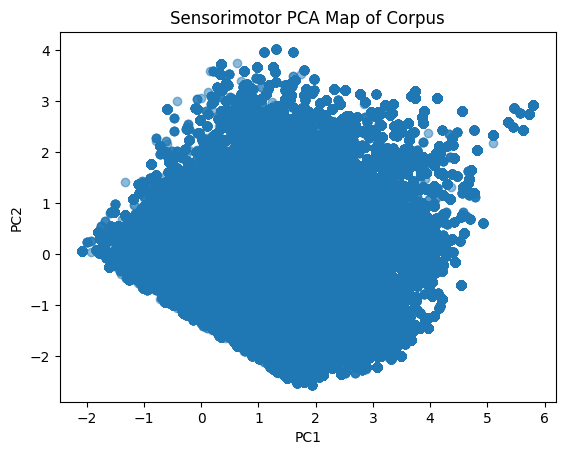

In [ ]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(merged[senses].fillna(0))

plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.5)
plt.title("Senses PCA Map of Corpus")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

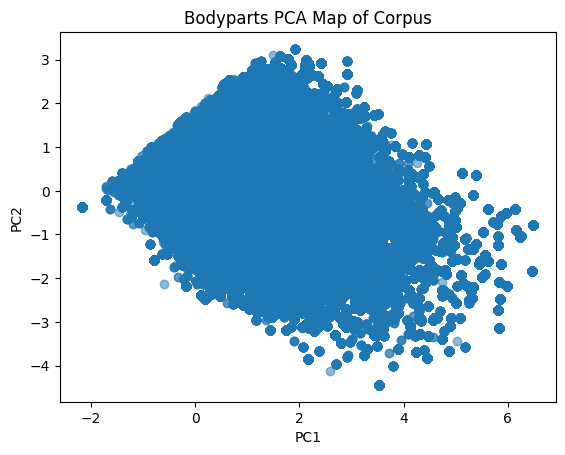

In [44]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(merged[bodyparts].fillna(0))

plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.5)
plt.title("Bodyparts PCA Map of Corpus")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [60]:
# Randomly sample e.g. 50,000 rows for visualization
df_sample = merged_lemmatized.sample(n=50000, random_state=42)  # adjust n as needed

# Fill missing values and run PCA on the modality columns
X = df_sample[modalities].fillna(0)
pca = PCA(n_components=2)
reduced = pca.fit_transform(X)

# Add PCA components to your dataframe
df_sample["PC1"] = reduced[:, 0]
df_sample["PC2"] = reduced[:, 1]

for modality in modalities:
    plt.figure(figsize=(6, 5))
    sns.scatterplot(
        data=df_sample,
        x="PC1", y="PC2",
        hue=modality,
        palette="viridis",
        s=10,       # smaller dots for speed
        alpha=0.7,  # transparency helps visibility
        edgecolor=None
    )
    plt.title(f"PCA colored by {modality}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.savefig(f"pca_{modality}.png", dpi=150)
    plt.close()


# Correlation Matrix between Modalities

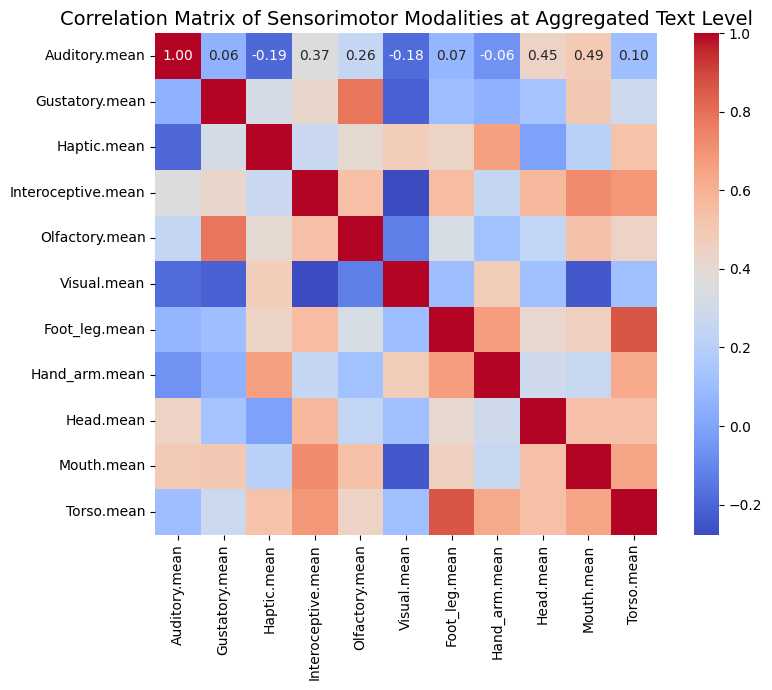

In [20]:
# Compute correlation matrix
corr = df[modalities].corr()

# Visualize
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,       # show correlation coefficients
    fmt=".2f",        # format to 2 decimals
    cmap="coolwarm",  # color scale
    square=True
)
plt.title("Correlation Matrix of Sensorimotor Modalities at Aggregated Text Level", size=14)
plt.tight_layout()
plt.show()

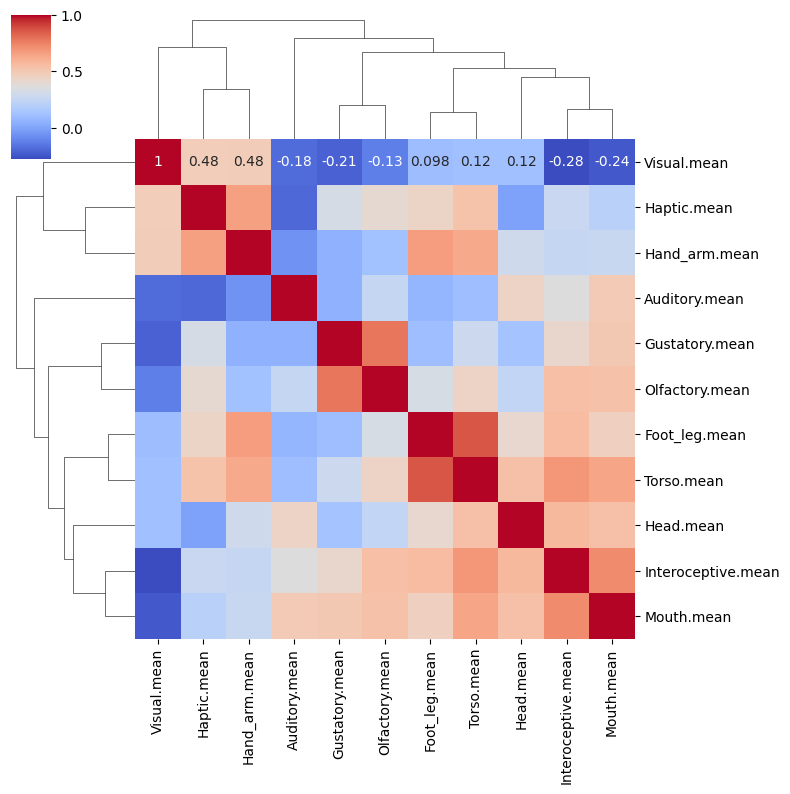

In [18]:
sns.clustermap(corr, annot=True, cmap="coolwarm", figsize=(8, 8))

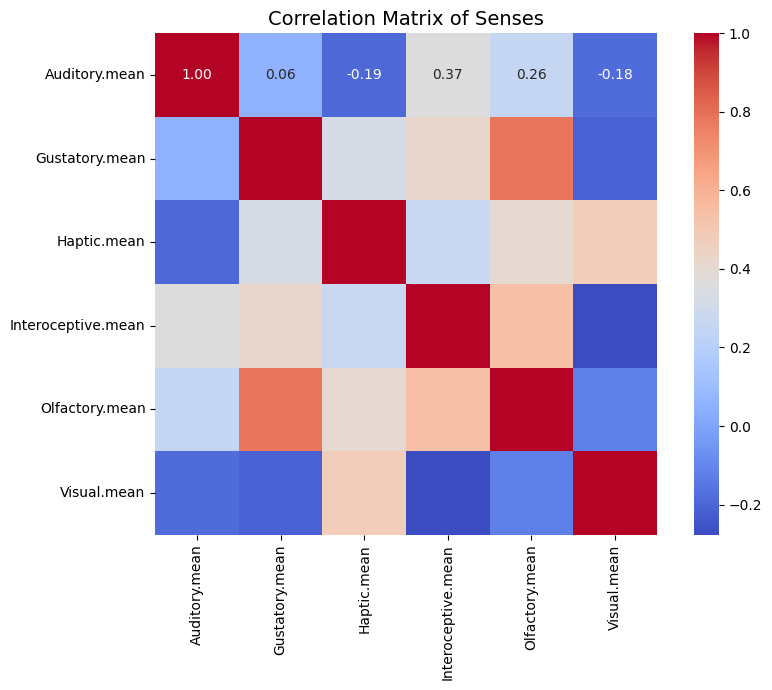

In [21]:
corr = df[senses].corr()
# Visualize
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,       # show correlation coefficients
    fmt=".2f",        # format to 2 decimals
    cmap="coolwarm",  # color scale
    square=True
)
plt.title("Correlation Matrix of Senses", size=14)
plt.tight_layout()
plt.show()